# 175 years of Atlantic hurricanes, in plain SQL

**1,988 storms and 55,524 observations, 1851 to 2025**, from the National Hurricane Center's best-track database (HURDAT2). Hurricane records are a classic case of data that changes quality over time: ships found storms until the 1960s, satellites after. So the interesting SQL is not only counting but **asking whether a trend is real**. The toolbox: a moving average with `ROWS BETWEEN` frames, `CASE` categories on the Saffir-Simpson scale, a **self-join on time** to compare a storm with itself 24 hours earlier (rapid intensification), an energy index summed from squared wind speeds, `ROW_NUMBER` to pick the first and the peak observation of each storm, and **gaps and islands** for streaks of seasons. Python only runs the queries and draws the charts.

**Data:** the [HURDAT2 Atlantic file](https://www.nhc.noaa.gov/data/hurdat/) (a text file of about 7 MB, public domain, through the 2025 season). Run `python build_db.py` once to parse it into a SQLite database, then point `HURRICANE_DB` at that file.

**Reading the data.** Winds are maximum sustained winds in **knots** (1 knot is 1.15 mph). A *named storm* has peak winds of at least 34 knots, a *hurricane* 64 knots (category 1) and a *major hurricane* 96 knots (category 3 or more). The older the record, the less certain the winds, and before the first weather satellites (1966) storms that never came near land or a shipping lane were often missed. Pressure is missing for 703 of the storms.

In [1]:
import os
import sqlite3
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

DB_PATH = Path(os.environ.get("HURRICANE_DB", "hurricanes.db"))
AMBER, BLUE, GREY = "#e8a33d", "#2b6cb0", "#a0aec0"
plt.rcParams.update({"axes.spines.top": False, "axes.spines.right": False, "axes.grid": True,
                     "grid.alpha": 0.25, "figure.dpi": 110})
pd.set_option("display.width", 120)
pd.set_option("display.max_columns", 20)

con = sqlite3.connect(DB_PATH)


def q(sql):
    """Run a query and return the result as a DataFrame."""
    return pd.read_sql_query(sql, con)

## 0. What is in the database?

In [2]:
tables = q("SELECT name FROM sqlite_master WHERE type = 'table' ORDER BY name").name
pd.DataFrame({"table": tables,
              "rows": [con.execute(f'SELECT COUNT(*) FROM "{t}"').fetchone()[0] for t in tables]})

,table,rows
0,storms,1988
1,tracks,55524


## 1. How active was each season?

Storms per season by strength, with a 10-season moving average from a window frame (`ROWS BETWEEN 9 PRECEDING AND CURRENT ROW`).

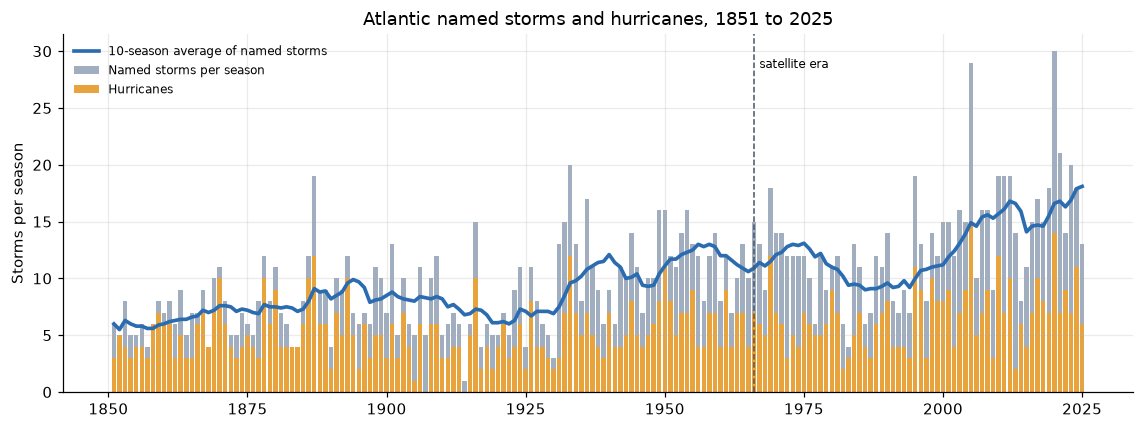

,year,named_storms,hurricanes,major_hurricanes,named_storms_10yr_avg
169,2020,30,14,7,16.6
154,2005,29,15,7,14.9
170,2021,21,7,4,16.8
82,1933,20,12,6,9.6
172,2023,20,7,3,16.9


In [3]:
seasons = q("""
WITH y AS (
    SELECT year,
           SUM(peak_wind_kt >= 34) AS named_storms,
           SUM(peak_wind_kt >= 64) AS hurricanes,
           SUM(peak_wind_kt >= 96) AS major_hurricanes
    FROM storms
    GROUP BY year
)
SELECT year, named_storms, hurricanes, major_hurricanes,
       ROUND(AVG(named_storms) OVER (ORDER BY year ROWS BETWEEN 9 PRECEDING AND CURRENT ROW), 1) AS named_storms_10yr_avg
FROM y
ORDER BY year
""")

fig, ax = plt.subplots(figsize=(10.5, 4))
ax.bar(seasons.year, seasons.named_storms, color=GREY, label="Named storms per season")
ax.bar(seasons.year, seasons.hurricanes, color=AMBER, label="Hurricanes")
ax.plot(seasons.year, seasons.named_storms_10yr_avg, color=BLUE, lw=2.4, label="10-season average of named storms")
ax.axvline(1966, color="#4a5568", ls="--", lw=1)
ax.text(1967, seasons.named_storms.max() * 0.98, "satellite era", fontsize=8, va="top")
ax.set_ylabel("Storms per season")
ax.legend(frameon=False, fontsize=8, loc="upper left")
ax.set_title("Atlantic named storms and hurricanes, 1851 to 2025")
fig.tight_layout()
plt.show()
seasons.sort_values("named_storms", ascending=False).head(5)

## 2. Are there more storms, or just better detection?

Periods of the record are compared with `CASE`: storms per season, the share that lasted less than two days (the kind that ships easily missed) and the share that never reached hurricane strength. If detection improved, short storms should become much more common.

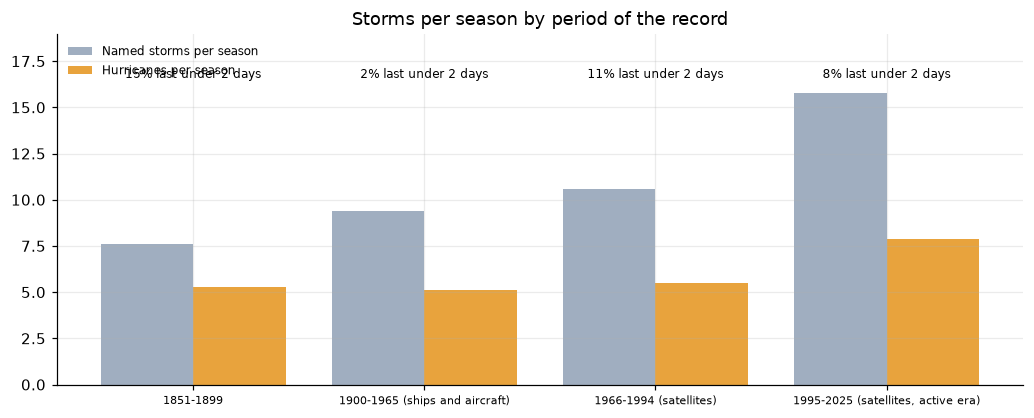

,period,seasons,named_storms_per_season,hurricanes_per_season,major_per_season,short_lived_pct
0,1) 1851-1899,49,7.6,5.3,1.2,15.1
1,2) 1900-1965 (ships and aircraft),66,9.4,5.1,1.9,1.8
2,3) 1966-1994 (satellites),29,10.6,5.5,1.7,11.3
3,"4) 1995-2025 (satellites, active era)",31,15.8,7.9,3.6,8.1


In [4]:
era = q("""
SELECT CASE WHEN year < 1900 THEN '1) 1851-1899'
            WHEN year < 1966 THEN '2) 1900-1965 (ships and aircraft)'
            WHEN year < 1995 THEN '3) 1966-1994 (satellites)'
            ELSE                  '4) 1995-2025 (satellites, active era)' END      AS period,
       COUNT(DISTINCT year)                                                          AS seasons,
       ROUND(1.0 * SUM(peak_wind_kt >= 34) / COUNT(DISTINCT year), 1)                AS named_storms_per_season,
       ROUND(1.0 * SUM(peak_wind_kt >= 64) / COUNT(DISTINCT year), 1)                AS hurricanes_per_season,
       ROUND(1.0 * SUM(peak_wind_kt >= 96) / COUNT(DISTINCT year), 1)                AS major_per_season,
       ROUND(100.0 * AVG(julianday(last_obs) - julianday(first_obs) < 2), 1)         AS short_lived_pct
FROM storms
GROUP BY period
ORDER BY period
""")

fig, ax = plt.subplots(figsize=(9.5, 3.9))
x = np.arange(len(era))
ax.bar(x - 0.2, era.named_storms_per_season, width=0.4, color=GREY, label="Named storms per season")
ax.bar(x + 0.2, era.hurricanes_per_season, width=0.4, color=AMBER, label="Hurricanes per season")
for i, s in enumerate(era.short_lived_pct):
    ax.text(i, era.named_storms_per_season.max() * 1.05, f"{s:.0f}% last under 2 days", ha="center", fontsize=8)
ax.set_xticks(x)
ax.set_xticklabels(era.period.str[3:], fontsize=7.5)
ax.set_ylim(0, era.named_storms_per_season.max() * 1.2)
ax.legend(frameon=False, fontsize=8, loc="upper left")
ax.set_title("Storms per season by period of the record")
fig.tight_layout()
plt.show()
era

## 3. How strong do the strongest get?

A `CASE` on peak wind assigns the Saffir-Simpson category, and conditional counts pivot it by decade. The last row (2020s) has six seasons.

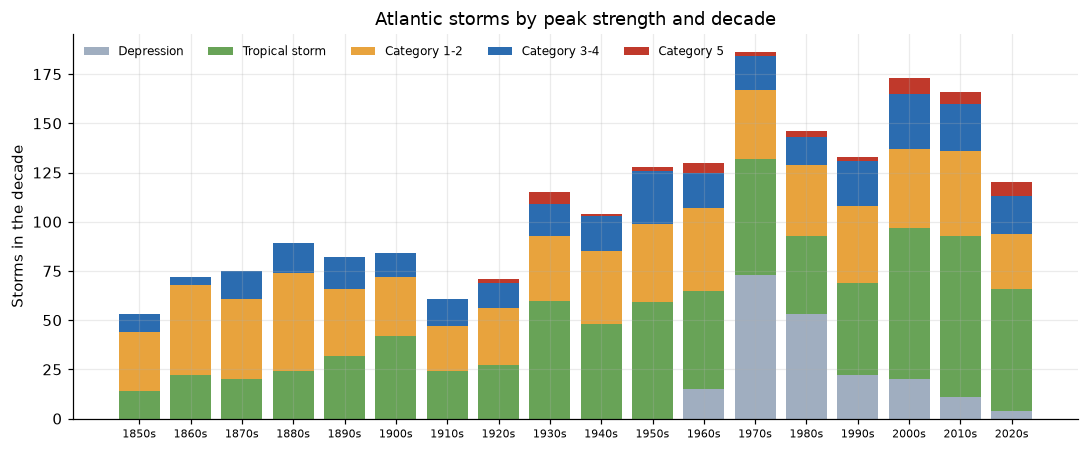

,decade,storms,depression,tropical_storm,cat_1_2,cat_3_4,cat_5,major_share_of_hurricanes_pct
12,1970,186,73,59,35,17,2,35.2
13,1980,146,53,40,36,14,3,32.1
14,1990,133,22,47,39,23,2,39.1
15,2000,173,20,77,40,28,8,47.4
16,2010,166,11,82,43,24,6,41.1
17,2020,120,4,62,28,19,7,48.1


In [5]:
categories = q("""
SELECT (year / 10) * 10                                                     AS decade,
       COUNT(*)                                                             AS storms,
       SUM(peak_wind_kt < 34)                                               AS depression,
       SUM(peak_wind_kt >= 34 AND peak_wind_kt < 64)                        AS tropical_storm,
       SUM(peak_wind_kt >= 64 AND peak_wind_kt < 96)                        AS cat_1_2,
       SUM(peak_wind_kt >= 96 AND peak_wind_kt < 137)                       AS cat_3_4,
       SUM(peak_wind_kt >= 137)                                             AS cat_5,
       ROUND(100.0 * SUM(peak_wind_kt >= 96) / NULLIF(SUM(peak_wind_kt >= 64), 0), 1) AS major_share_of_hurricanes_pct
FROM storms
GROUP BY decade
ORDER BY decade
""")

cols = ["depression", "tropical_storm", "cat_1_2", "cat_3_4", "cat_5"]
labels = ["Depression", "Tropical storm", "Category 1-2", "Category 3-4", "Category 5"]
fig, ax = plt.subplots(figsize=(10, 4.2))
bottom = np.zeros(len(categories))
for col, lab, color in zip(cols, labels, [GREY, "#68a357", AMBER, BLUE, "#c0392b"]):
    ax.bar(categories.decade.astype(str) + "s", categories[col], bottom=bottom, label=lab, color=color)
    bottom += categories[col].values
ax.set_ylabel("Storms in the decade")
ax.tick_params(axis="x", labelsize=7)
ax.legend(frameon=False, fontsize=8, ncol=5, loc="upper left")
ax.set_title("Atlantic storms by peak strength and decade")
fig.tight_layout()
plt.show()
categories.tail(6)

## 4. When is the season?

Storms grouped by the month of their first observation. `RANK()` over the count puts the busiest month first.

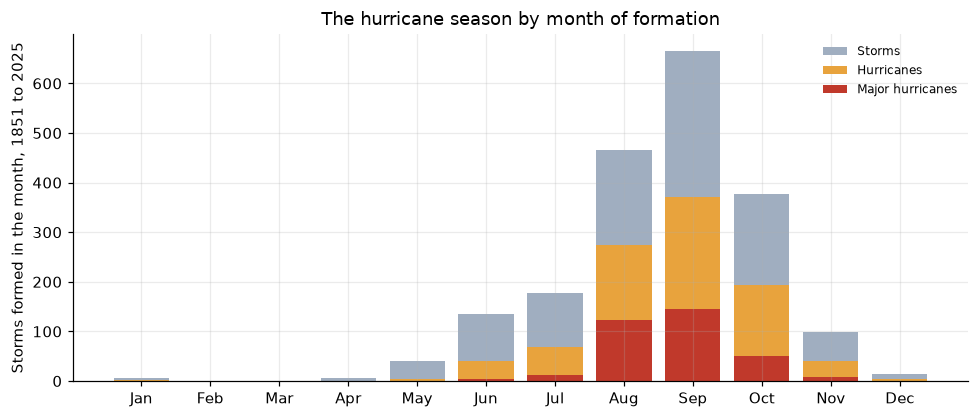

,month,storms,share_pct,busiest_rank
0,1,6,0.3,9
1,2,1,0.1,11
2,3,1,0.1,11
3,4,6,0.3,9
4,5,40,2.0,7
5,6,136,6.8,5
6,7,177,8.9,4
7,8,465,23.4,2
8,9,666,33.5,1
9,10,378,19.0,3


In [6]:
months = q("""
SELECT CAST(substr(first_obs, 6, 2) AS INT)                          AS month,
       COUNT(*)                                                      AS storms,
       SUM(peak_wind_kt >= 64)                                       AS hurricanes,
       SUM(peak_wind_kt >= 96)                                       AS major_hurricanes,
       ROUND(100.0 * COUNT(*) / SUM(COUNT(*)) OVER (), 1)            AS share_pct,
       ROUND(AVG(peak_wind_kt))                                      AS avg_peak_wind_kt,
       RANK() OVER (ORDER BY COUNT(*) DESC)                          AS busiest_rank
FROM storms
GROUP BY month
ORDER BY month
""")

names = ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]
fig, ax = plt.subplots(figsize=(9, 3.9))
ax.bar([names[m - 1] for m in months.month], months.storms, color=GREY, label="Storms")
ax.bar([names[m - 1] for m in months.month], months.hurricanes, color=AMBER, label="Hurricanes")
ax.bar([names[m - 1] for m in months.month], months.major_hurricanes, color="#c0392b", label="Major hurricanes")
ax.set_ylabel("Storms formed in the month, 1851 to 2025")
ax.legend(frameon=False, fontsize=8)
ax.set_title("The hurricane season by month of formation")
fig.tight_layout()
plt.show()
months[["month", "storms", "share_pct", "busiest_rank"]]

## 5. Which seasons carried the most energy?

Accumulated cyclone energy (ACE) adds up the squared maximum wind of every regular 6-hourly observation of a tropical storm or hurricane, divided by 10,000. It rewards storms that are both strong and long-lived. `RANK()` orders the seasons.

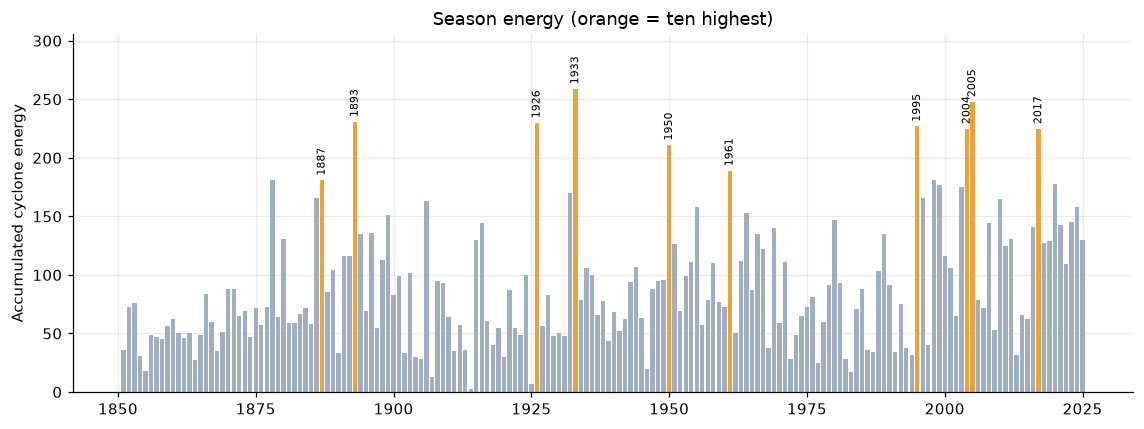

,year,storms,ace,rank
82,1933,20,259.0,1
154,2005,27,248.0,2
42,1893,12,231.0,3
75,1926,11,230.0,4
144,1995,19,227.0,5
166,2017,17,225.0,6
153,2004,14,225.0,7
99,1950,16,211.0,8
110,1961,12,189.0,9
36,1887,19,181.0,10


In [7]:
ace = q("""
WITH a AS (
    SELECT s.year, t.storm_id, t.max_wind_kt
    FROM tracks t
    JOIN storms s USING (storm_id)
    WHERE substr(t.obs_time, 12, 5) IN ('00:00', '06:00', '12:00', '18:00') AND t.max_wind_kt >= 34 AND t.status IN ('TS', 'HU')
)
SELECT year,
       COUNT(DISTINCT storm_id)                          AS storms,
       ROUND(SUM(max_wind_kt * max_wind_kt) / 10000.0)   AS ace,
       RANK() OVER (ORDER BY SUM(max_wind_kt * max_wind_kt) DESC) AS rank
FROM a
GROUP BY year
ORDER BY year
""")

fig, ax = plt.subplots(figsize=(10.5, 4))
ax.bar(ace.year, ace.ace, color=[AMBER if r <= 10 else GREY for r in ace["rank"]])
top = ace.sort_values("rank").head(10)
for _, r in top.iterrows():
    ax.text(r.year, r.ace + 6, int(r.year), ha="center", fontsize=7, rotation=90)
ax.set_ylabel("Accumulated cyclone energy")
ax.set_ylim(0, ace.ace.max() * 1.18)
ax.set_title("Season energy (orange = ten highest)")
fig.tight_layout()
plt.show()
ace.sort_values("rank").head(10)

## 6. Which storms were the most intense?

Ranking storms by peak wind, with the lowest central pressure as the tie-break, and the same storms by pressure alone (`RANK()` over each), shows that the two measures do not always agree.

In [8]:
intense = q("""
SELECT RANK() OVER (ORDER BY peak_wind_kt DESC, lowest_pressure_mb)  AS rank_by_wind,
       RANK() OVER (ORDER BY lowest_pressure_mb)                     AS rank_by_pressure,
       COALESCE(name, 'unnamed') || ' ' || year                      AS storm,
       peak_wind_kt,
       ROUND(peak_wind_kt * 1.15078)                                 AS peak_wind_mph,
       lowest_pressure_mb,
       ROUND(julianday(last_obs) - julianday(first_obs), 1)          AS lifetime_days
FROM storms
WHERE lowest_pressure_mb IS NOT NULL
ORDER BY rank_by_wind
LIMIT 12
""")

intense

,rank_by_wind,rank_by_pressure,storm,peak_wind_kt,peak_wind_mph,lowest_pressure_mb,lifetime_days
0,1,3,Melissa 2025,165.0,190.0,892.0,11.0
1,2,7,Allen 1980,165.0,190.0,899.0,11.3
2,3,1,Wilma 2005,160.0,184.0,882.0,11.0
3,4,2,Gilbert 1988,160.0,184.0,888.0,11.3
4,5,3,unnamed 1935,160.0,184.0,892.0,12.3
5,6,13,Dorian 2019,160.0,184.0,910.0,15.8
6,7,5,Milton 2024,155.0,178.0,895.0,7.0
7,7,5,Rita 2005,155.0,178.0,895.0,8.3
8,9,10,Mitch 1998,155.0,178.0,905.0,18.8
9,10,17,Irma 2017,155.0,178.0,914.0,14.5


## 7. Do storms intensify faster than they used to?

A self-join on time compares each observation with the one exactly 24 hours earlier in the same storm (`strftime('%Y-%m-%d %H:%M', obs_time, '-24 hours')`). The largest 24-hour wind gain of each storm is its rapid intensification score, and a gain of 30 knots or more counts as rapid intensification. Only storms that became hurricanes are included.

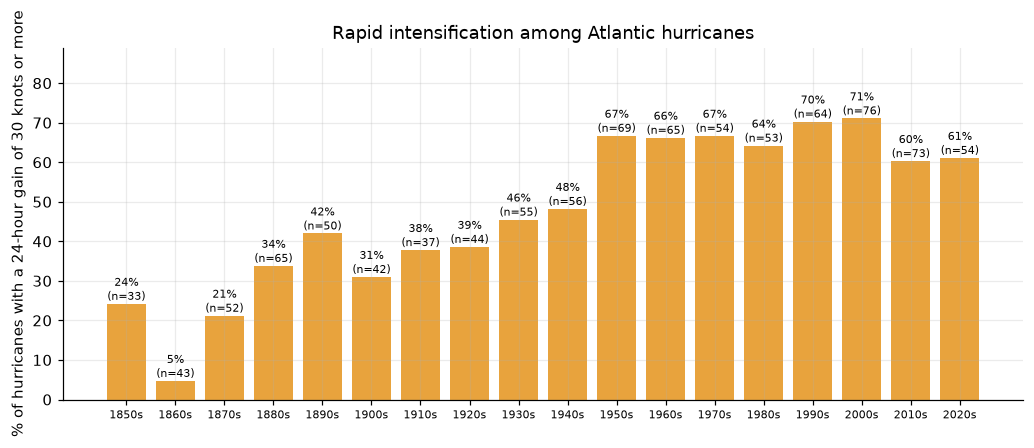

,decade,hurricanes,rapidly_intensifying,rapid_pct,avg_max_gain_kt,fastest_gain_kt
12,1970,54,36,66.7,33.9,65.0
13,1980,53,34,64.2,31.1,60.0
14,1990,64,45,70.3,32.4,65.0
15,2000,76,54,71.1,36.5,95.0
16,2010,73,44,60.3,33.0,75.0
17,2020,54,33,61.1,36.9,80.0


In [9]:
rapid = q("""
WITH gains AS (
    SELECT a.storm_id, MAX(a.max_wind_kt - b.max_wind_kt) AS max_gain_24h
    FROM tracks a
    JOIN tracks b ON b.storm_id = a.storm_id AND b.obs_time = strftime('%Y-%m-%d %H:%M', a.obs_time, '-24 hours')
    WHERE a.max_wind_kt IS NOT NULL AND b.max_wind_kt IS NOT NULL
    GROUP BY a.storm_id
)
SELECT (s.year / 10) * 10                                         AS decade,
       COUNT(*)                                                    AS hurricanes,
       SUM(g.max_gain_24h >= 30)                                   AS rapidly_intensifying,
       ROUND(100.0 * AVG(g.max_gain_24h >= 30), 1)                 AS rapid_pct,
       ROUND(AVG(g.max_gain_24h), 1)                               AS avg_max_gain_kt,
       MAX(g.max_gain_24h)                                         AS fastest_gain_kt
FROM storms s
JOIN gains g USING (storm_id)
WHERE s.peak_wind_kt >= 64
GROUP BY decade
ORDER BY decade
""")

fig, ax = plt.subplots(figsize=(9.5, 3.9))
ax.bar(rapid.decade.astype(str) + "s", rapid.rapid_pct, color=AMBER)
for x, (p, n) in enumerate(zip(rapid.rapid_pct, rapid.hurricanes)):
    ax.text(x, p + 1, f"{p:.0f}%\n(n={n})", ha="center", fontsize=7.5)
ax.set_ylim(0, rapid.rapid_pct.max() * 1.25)
ax.set_ylabel("% of hurricanes with a 24-hour gain of 30 knots or more")
ax.tick_params(axis="x", labelsize=7)
ax.set_title("Rapid intensification among Atlantic hurricanes")
fig.tight_layout()
plt.show()
rapid.tail(6)

## 8. How often do hurricanes make landfall?

Observations marked `L` in the source are landfalls. Counting them by decade, by strength at the moment of landfall, shows how often a storm of hurricane strength crossed a coast (a storm that crosses several islands counts each time).

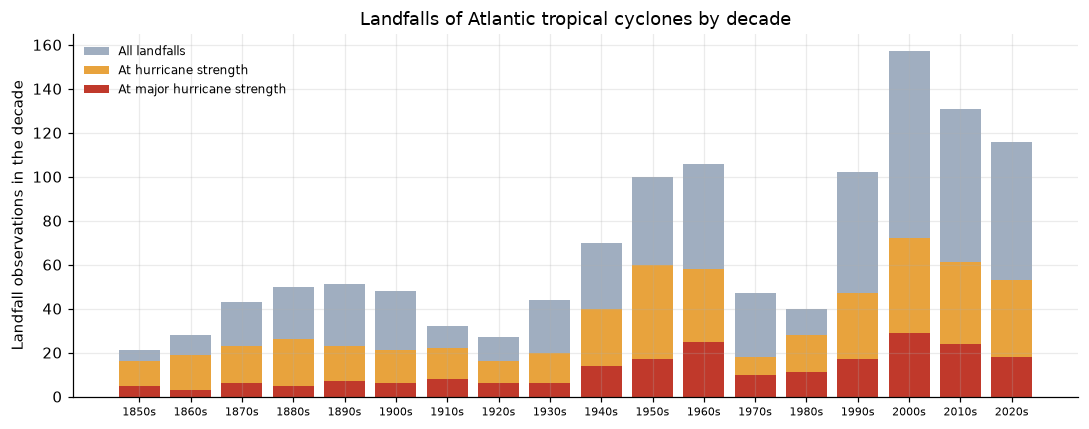

,decade,landfalls,hurricane_landfalls,major_landfalls,strongest_kt
12,1970,47,18,10,135.0
13,1980,40,28,11,140.0
14,1990,102,47,17,145.0
15,2000,157,72,29,150.0
16,2010,131,61,24,160.0
17,2020,116,53,18,160.0


In [10]:
landfalls = q("""
SELECT (CAST(substr(obs_time, 1, 4) AS INT) / 10) * 10         AS decade,
       COUNT(*)                                                AS landfalls,
       SUM(max_wind_kt >= 64)                                  AS hurricane_landfalls,
       SUM(max_wind_kt >= 96)                                  AS major_landfalls,
       MAX(max_wind_kt)                                        AS strongest_kt
FROM tracks
WHERE record_id = 'L'
GROUP BY decade
ORDER BY decade
""")

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(landfalls.decade.astype(str) + "s", landfalls.landfalls, color=GREY, label="All landfalls")
ax.bar(landfalls.decade.astype(str) + "s", landfalls.hurricane_landfalls, color=AMBER, label="At hurricane strength")
ax.bar(landfalls.decade.astype(str) + "s", landfalls.major_landfalls, color="#c0392b", label="At major hurricane strength")
ax.tick_params(axis="x", labelsize=7)
ax.set_ylabel("Landfall observations in the decade")
ax.legend(frameon=False, fontsize=8, loc="upper left")
ax.set_title("Landfalls of Atlantic tropical cyclones by decade")
fig.tight_layout()
plt.show()
landfalls.tail(6)

## 9. Longest runs of seasons with and without a major hurricane

Gaps and islands on the calendar: for each season, did at least one major hurricane form? Subtracting the row number among seasons of the same kind from the overall row number gives the same value for consecutive seasons of one kind, so grouping by it yields the runs.

In [11]:
streaks = q("""
WITH y AS (
    SELECT year, MAX(peak_wind_kt >= 96) AS had_major
    FROM storms
    GROUP BY year
),
n AS (
    SELECT year, had_major,
           ROW_NUMBER() OVER (ORDER BY year)                         AS rn,
           ROW_NUMBER() OVER (PARTITION BY had_major ORDER BY year)  AS rn_kind
    FROM y
),
runs AS (
    SELECT had_major, rn - rn_kind AS grp, MIN(year) AS from_year, MAX(year) AS to_year, COUNT(*) AS seasons
    FROM n
    GROUP BY had_major, grp
)
SELECT CASE WHEN had_major = 1 THEN 'with a major hurricane' ELSE 'without one' END AS kind,
       from_year, to_year, seasons
FROM runs
ORDER BY seasons DESC
LIMIT 10
""")

streaks

,kind,from_year,to_year,seasons
0,with a major hurricane,1995,2012,18
1,with a major hurricane,1947,1961,15
2,with a major hurricane,1926,1939,14
3,with a major hurricane,1973,1985,13
4,with a major hurricane,2014,2025,12
5,with a major hurricane,1987,1993,7
6,with a major hurricane,1851,1856,6
7,with a major hurricane,1875,1880,6
8,without one,1861,1865,5
9,with a major hurricane,1915,1919,5


## 10. Where do storms start, and has that moved?

`ROW_NUMBER()` picks two observations of every storm: the first at tropical-storm strength (where it became a named storm) and the one with the highest wind (where it peaked). Their average latitude and longitude by decade show whether the storm tracks have shifted, for storms from 1900 on.

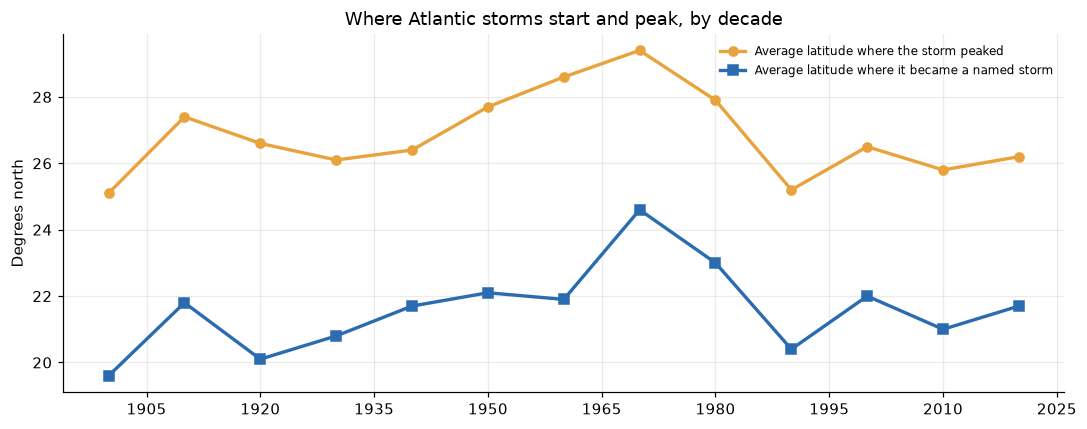

,decade,storms,avg_lat_named,avg_lon_named,avg_lat_at_peak,avg_lon_at_peak
0,1900,84,19.6,-66.4,25.1,-73.6
1,1910,61,21.8,-67.8,27.4,-75.6
2,1920,71,20.1,-66.6,26.6,-70.5
3,1930,115,20.8,-68.6,26.1,-73.7
4,1940,104,21.7,-70.2,26.4,-74.5
5,1950,128,22.1,-66.1,27.7,-70.4
6,1960,115,21.9,-61.8,28.6,-64.9
7,1970,113,24.6,-66.4,29.4,-68.0
8,1980,93,23.0,-63.2,27.9,-66.2
9,1990,111,20.4,-60.9,25.2,-64.4


In [12]:
genesis = q("""
WITH first_ts AS (
    SELECT storm_id, lat, lon,
           ROW_NUMBER() OVER (PARTITION BY storm_id ORDER BY obs_time) AS rn
    FROM tracks
    WHERE max_wind_kt >= 34
),
peak AS (
    SELECT storm_id, lat, lon,
           ROW_NUMBER() OVER (PARTITION BY storm_id ORDER BY max_wind_kt DESC, obs_time) AS rn
    FROM tracks
    WHERE max_wind_kt IS NOT NULL
)
SELECT (s.year / 10) * 10                  AS decade,
       COUNT(*)                            AS storms,
       ROUND(AVG(f.lat), 1)                AS avg_lat_named,
       ROUND(AVG(f.lon), 1)                AS avg_lon_named,
       ROUND(AVG(p.lat), 1)                AS avg_lat_at_peak,
       ROUND(AVG(p.lon), 1)                AS avg_lon_at_peak
FROM storms s
JOIN first_ts f ON f.storm_id = s.storm_id AND f.rn = 1
JOIN peak     p ON p.storm_id = s.storm_id AND p.rn = 1
WHERE s.year >= 1900
GROUP BY decade
ORDER BY decade
""")

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(genesis.decade, genesis.avg_lat_at_peak, color=AMBER, marker="o", lw=2.2, label="Average latitude where the storm peaked")
ax.plot(genesis.decade, genesis.avg_lat_named, color=BLUE, marker="s", lw=2.2, label="Average latitude where it became a named storm")
ax.set_ylabel("Degrees north")
ax.xaxis.set_major_locator(plt.MaxNLocator(integer=True))
ax.legend(frameon=False, fontsize=8)
ax.set_title("Where Atlantic storms start and peak, by decade")
fig.tight_layout()
plt.show()
genesis

## What the queries say

- **Recent seasons are the busiest on record, but the record is not comparable.** 2020 had 30 named storms and 2005 had 29, the two highest counts since 1851, and the 10-season average reached 18.1 in 2025 against about 12 in the 1960s and 1970s. Since 1995 a season has averaged 15.8 named storms, 7.9 hurricanes and 3.6 major hurricanes, against 7.6, 5.3 and 1.2 in 1851-99.
- **Part of the older record is missing storms, but not the hurricanes.** Named storms per season rose from 7.6 (1851-99) to 9.4 (1900-65) and 10.6 (1966-94), which is consistent with undercounting before satellites, but hurricanes (the storms that tend to hit land and get noticed) were steady at 5.1 to 5.5 per season until 1994. The step to 7.9 hurricanes and 15.8 named storms after 1995 is therefore large against a stable baseline, and it is not an artefact of satellites, which were there in 1966-94 as well. The share of storms lasting under two days does not trend (15% in 1851-99, 2% in 1900-65, 11% in 1966-94, 8% since 1995), so that check does not settle the question either way.
- **A larger share of hurricanes are major.** Category 3 or higher made up 32-42% of hurricanes in the 1950s to 1980s, 47% in the 2000s and 48% in the 2020s. In the 1850s to 1880s the share is 8-26%, but wind estimates for that period are too crude to compare. Category 5 storms: 8 in the 2000s, 6 in the 2010s and 7 in the 2020s (so far, six seasons), against 1 to 6 per decade before 2000.
- **September is the season.** 666 of 1,988 storms (33.5%) formed in September, 465 in August and 378 in October, so August to October holds 76% of all storms and 93% of major hurricanes (320 of 345). Only 68 storms formed outside June to November.
- **A few seasons stand out for energy.** By accumulated cyclone energy the ranking is 1933 (259), 2005 (248), 1893 (231), 1926 (230), 1995 (227), 2017 and 2004 (225 each). Three of the top seven are before 1950, and they are a reminder that very active seasons happened in the record before the recent rise.
- **The strongest storms are close to each other.** Melissa (2025) and Allen (1980) tie for the highest peak wind (165 knots, 190 mph), followed by Wilma (2005), Gilbert (1988), an unnamed 1935 storm and Dorian (2019) at 160 knots. By central pressure Wilma is first (882 mb), then Gilbert (888 mb). 703 of the 1,988 storms have no recorded pressure, so a pressure ranking covers only the other 1,285.
- **Rapid intensification is common in the data, and the record has grown in the last 20 years.** The share of hurricanes that gained 30 knots or more in 24 hours is 5-48% before 1950 (lowest in the 1860s) but 60-71% in every decade since 1950, with no clear trend within that period. The early figures are limited by coarse winds and sparse observations. The largest 24-hour gains are all recent: Wilma 2005 (95 knots), Felix 2007 (85), Milton 2024 (80), Matthew 2016 and Erin 2025 (75).
- **Landfalls follow the active periods.** The decade count of landfall observations was 40 to 47 in the 1970s and 1980s and 102 to 157 since the 1990s, with the highest in the 2000s (157, of which 72 at hurricane strength and 29 at major strength). A storm crossing several islands counts each time, and the pattern before 1940 reflects how few coastlines were observed.
- **Long streaks of major-hurricane seasons exist, and quiet streaks are short.** There was at least one major hurricane in every season from 1995 to 2012 (18 in a row), from 1947 to 1961 (15) and from 1926 to 1939 (14). The longest run of seasons with none is just 5 years (1861 to 1865).
- **The simple geography has not moved much.** The average latitude where storms became named storms was 19.6 to 24.6 degrees north in every decade since 1900, and where they peaked 25.1 to 29.4, with no steady shift north or south: the highest value is in the 1970s and the 2010s and 2020s are at 25.8 and 26.2.

**Limits.** Winds before about 1950 are estimates with large errors, and storms that stayed at sea before 1966 were often missed. Depressions are included only from the 1960s. Rapid intensification depends on how often a storm was observed. The satellite and aircraft eras both changed how winds are measured. Landfall counts count every crossing, not storms.
